<a href="https://colab.research.google.com/github/mhtabkrklt/ML-2/blob/main/ML_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Первые пять строк данных:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Количество пропущенных значений в каждом столбце:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


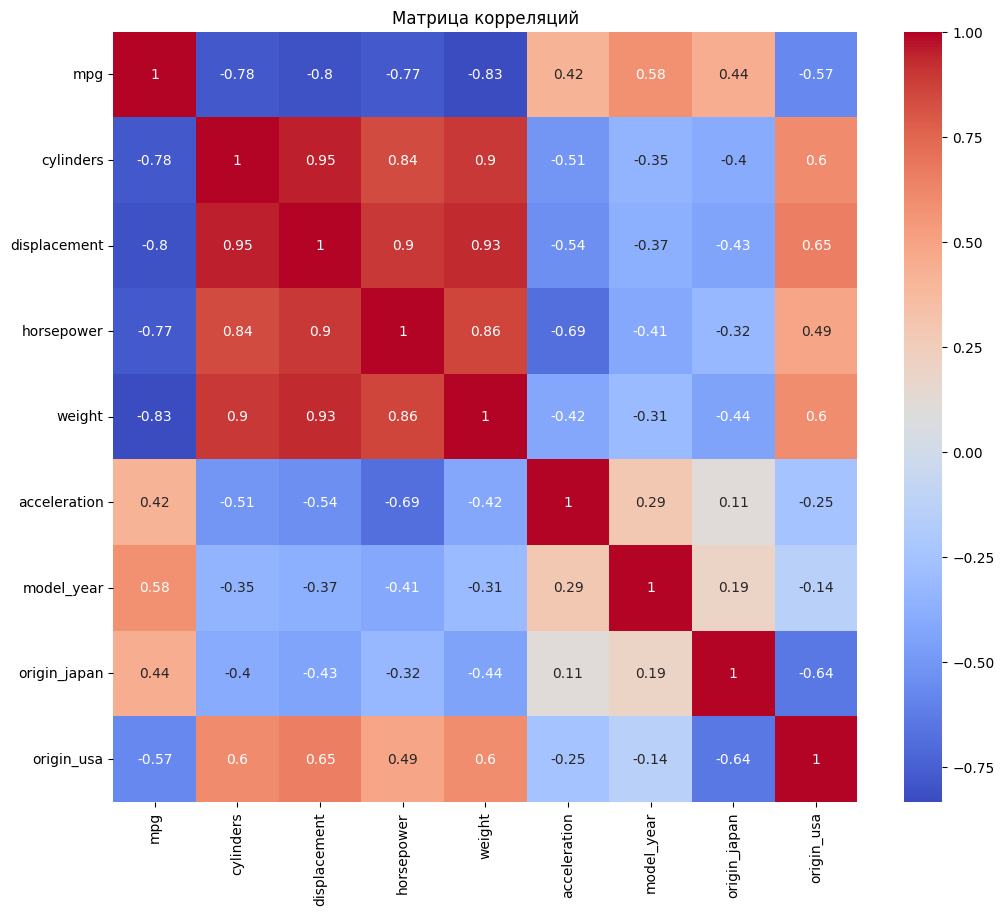


Лучшие гиперпараметры для градиентного спуска: alpha=0.1, lambda=0.01

Результаты модели градиентного спуска:
Обучающая выборка - MSE: 11.36, RMSE: 3.37, R²: 0.82
Тестовая выборка - MSE: 8.34, RMSE: 2.89, R²: 0.84

Лучшее значение alpha для Ridge Regression: 1

Результаты модели Ridge Regression:
Обучающая выборка - MSE: 11.36, RMSE: 3.37, R²: 0.82
Тестовая выборка - MSE: 8.34, RMSE: 2.89, R²: 0.84

Результаты кросс-валидации:
   Fold  mse_train   mse_test  rmse_train  rmse_test  r2_train   r2_test
0     1  11.355196   8.338634    3.369747   2.887669  0.818885  0.844910
1     2  10.731438  10.881800    3.275887   3.298757  0.823929  0.818537
2     3  11.057627   9.394320    3.325301   3.065016  0.822202  0.832053
3     4   9.632953  15.497279    3.103700   3.936658  0.832332  0.791725
4     5  10.327318  12.741677    3.213615   3.569549  0.831557  0.785230

Средние значения метрик:
Fold           3.000000
mse_train     10.620906
mse_test      11.370742
rmse_train     3.257650
rmse_tes

In [ ]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE

# Загрузка данных
df = sns.load_dataset('mpg')

# Первичный анализ данных
print("Первые пять строк данных:")
print(df.head())

# Проверка на пропущенные значения
print("\nКоличество пропущенных значений в каждом столбце:")
print(df.isnull().sum())
# Преобразование категориальных признаков в числовые
df = pd.get_dummies(df, columns=['origin'], drop_first=True)

# Удаление ненужных признаков
df = df.drop('name', axis=1)
# Очистка данных: заполнение пропущенных значений медианой
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

# Разведочный анализ данных (EDA)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()



# Разделение данных на признаки и целевую переменную
X = df.drop('mpg', axis=1)
y = df['mpg']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Добавление столбца единиц для интерсепта
X_train_scaled = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))
X_test_scaled = np.hstack((np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

# Реализация функции градиентного спуска с гиперпараметрами
def gradient_descent(X, y, alpha=0.01, iterations=10000, lambda_reg=0.1):
    m, n = X.shape
    w = np.zeros(n)
    for i in range(iterations):
        y_pred = X.dot(w)
        error = y_pred - y
        gradient = (1 / m) * (X.T.dot(error)) + (lambda_reg / m) * np.concatenate(([0], w[1:]))
        w = w - alpha * gradient
    return w

# Подбор гиперпараметров для градиентного спуска
alphas = [0.001, 0.01, 0.1]
lambdas = [0.01, 0.1, 1]
best_rmse = float('inf')
best_alpha = None
best_lambda = None
best_w = None

for alpha in alphas:
    for lambda_reg in lambdas:
        w = gradient_descent(X_train_scaled, y_train.values, alpha=alpha, iterations=10000, lambda_reg=lambda_reg)
        y_train_pred = X_train_scaled.dot(w)
        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
        if rmse_train < best_rmse:
            best_rmse = rmse_train
            best_alpha = alpha
            best_lambda = lambda_reg
            best_w = w

print(f"\nЛучшие гиперпараметры для градиентного спуска: alpha={best_alpha}, lambda={best_lambda}")

# Оценка модели с лучшими гиперпараметрами
y_train_pred = X_train_scaled.dot(best_w)
y_test_pred = X_test_scaled.dot(best_w)

mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("\nРезультаты модели градиентного спуска:")
print(f"Обучающая выборка - MSE: {mse_train:.2f}, RMSE: {rmse_train:.2f}, R²: {r2_train:.2f}")
print(f"Тестовая выборка - MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}, R²: {r2_test:.2f}")

# Обучение модели Ridge Regression с подбором гиперпараметров
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled[:, 1:], y_train)  # исключаем столбец единиц

best_alpha_ridge = ridge_cv.best_params_['alpha']
best_ridge = ridge_cv.best_estimator_

print(f"\nЛучшее значение alpha для Ridge Regression: {best_alpha_ridge}")

y_train_pred_ridge = best_ridge.predict(X_train_scaled[:, 1:])
y_test_pred_ridge = best_ridge.predict(X_test_scaled[:, 1:])

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
rmse_train_ridge = np.sqrt(mse_train_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
rmse_test_ridge = np.sqrt(mse_test_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)

print("\nРезультаты модели Ridge Regression:")
print(f"Обучающая выборка - MSE: {mse_train_ridge:.2f}, RMSE: {rmse_train_ridge:.2f}, R²: {r2_train_ridge:.2f}")
print(f"Тестовая выборка - MSE: {mse_test_ridge:.2f}, RMSE: {rmse_test_ridge:.2f}, R²: {r2_test_ridge:.2f}")

# Кросс-валидация с лучшими гиперпараметрами
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mse_train_list = []
mse_test_list = []
rmse_train_list = []
rmse_test_list = []
r2_train_list = []
r2_test_list = []

for train_index, test_index in kf.split(X):
    X_cv_train, X_cv_test = X.iloc[train_index], X.iloc[test_index]
    y_cv_train, y_cv_test = y.iloc[train_index], y.iloc[test_index]

    scaler_cv = StandardScaler()
    X_cv_train_scaled = scaler_cv.fit_transform(X_cv_train)
    X_cv_test_scaled = scaler_cv.transform(X_cv_test)

    X_cv_train_scaled = np.hstack((np.ones((X_cv_train_scaled.shape[0], 1)), X_cv_train_scaled))
    X_cv_test_scaled = np.hstack((np.ones((X_cv_test_scaled.shape[0], 1)), X_cv_test_scaled))

    w_cv = gradient_descent(X_cv_train_scaled, y_cv_train.values, alpha=best_alpha, iterations=10000, lambda_reg=best_lambda)

    y_cv_train_pred = X_cv_train_scaled.dot(w_cv)
    y_cv_test_pred = X_cv_test_scaled.dot(w_cv)

    mse_train_cv = mean_squared_error(y_cv_train, y_cv_train_pred)
    mse_test_cv = mean_squared_error(y_cv_test, y_cv_test_pred)
    rmse_train_cv = np.sqrt(mse_train_cv)
    rmse_test_cv = np.sqrt(mse_test_cv)
    r2_train_cv = r2_score(y_cv_train, y_cv_train_pred)
    r2_test_cv = r2_score(y_cv_test, y_cv_test_pred)

    mse_train_list.append(mse_train_cv)
    mse_test_list.append(mse_test_cv)
    rmse_train_list.append(rmse_train_cv)
    rmse_test_list.append(rmse_test_cv)
    r2_train_list.append(r2_train_cv)
    r2_test_list.append(r2_test_cv)

# Таблица с результатами кросс-валидации
results_df = pd.DataFrame({
    'Fold': range(1, 6),
    'mse_train': mse_train_list,
    'mse_test': mse_test_list,
    'rmse_train': rmse_train_list,
    'rmse_test': rmse_test_list,
    'r2_train': r2_train_list,
    'r2_test': r2_test_list
})

print("\nРезультаты кросс-валидации:")
print(results_df)

print("\nСредние значения метрик:")
print(results_df.mean())

print("\nСтандартное отклонение метрик:")
print(results_df.std())

# Подбор оптимального количества признаков с помощью RFE
ridge_for_rfe = Ridge(alpha=best_alpha_ridge)
selector = RFE(ridge_for_rfe, n_features_to_select=5)
selector = selector.fit(X_train_scaled[:, 1:], y_train)  # исключаем столбец единиц

selected_features = X.columns[selector.support_]
print("\nВыбранные признаки с помощью RFE:")
print(selected_features)

# Обучение модели с выбранными признаками
X_train_selected = X_train_scaled[:, np.concatenate(([0], selector.support_ + 1))]
X_test_selected = X_test_scaled[:, np.concatenate(([0], selector.support_ + 1))]

w_selected = gradient_descent(X_train_selected, y_train.values, alpha=best_alpha, iterations=10000, lambda_reg=best_lambda)

y_train_pred_selected = X_train_selected.dot(w_selected)
y_test_pred_selected = X_test_selected.dot(w_selected)

mse_train_selected = mean_squared_error(y_train, y_train_pred_selected)
rmse_train_selected = np.sqrt(mse_train_selected)
r2_train_selected = r2_score(y_train, y_train_pred_selected)

mse_test_selected = mean_squared_error(y_test, y_test_pred_selected)
rmse_test_selected = np.sqrt(mse_test_selected)
r2_test_selected = r2_score(y_test, y_test_pred_selected)

print("\nРезультаты модели с выбранными признаками:")
print(f"Обучающая выборка - MSE: {mse_train_selected:.2f}, RMSE: {rmse_train_selected:.2f}, R²: {r2_train_selected:.2f}")
print(f"Тестовая выборка - MSE: {mse_test_selected:.2f}, RMSE: {rmse_test_selected:.2f}, R²: {r2_test_selected:.2f}")

# Реализация стохастического градиентного спуска
def stochastic_gradient_descent(X, y, alpha=0.01, iterations=10000, lambda_reg=0.1):
    m, n = X.shape
    w = np.zeros(n)
    for i in range(iterations):
        idx = np.random.randint(m)
        xi = X[idx, :].reshape(1, -1)
        yi = y[idx]
        y_pred = xi.dot(w)
        error = y_pred - yi
        gradient = xi.T * error + lambda_reg * np.concatenate(([0], w[1:])).reshape(-1,1)
        w = w - alpha * gradient.flatten()
    return w

w_sgd = stochastic_gradient_descent(X_train_scaled, y_train.values, alpha=best_alpha, iterations=10000, lambda_reg=best_lambda)

y_train_pred_sgd = X_train_scaled.dot(w_sgd)
y_test_pred_sgd = X_test_scaled.dot(w_sgd)

mse_train_sgd = mean_squared_error(y_train, y_train_pred_sgd)
rmse_train_sgd = np.sqrt(mse_train_sgd)
r2_train_sgd = r2_score(y_train, y_train_pred_sgd)

mse_test_sgd = mean_squared_error(y_test, y_test_pred_sgd)
rmse_test_sgd = np.sqrt(mse_test_sgd)
r2_test_sgd = r2_score(y_test, y_test_pred_sgd)

print("\nРезультаты модели Стохастического Градиентного Спуска:")
print(f"Обучающая выборка - MSE: {mse_train_sgd:.2f}, RMSE: {rmse_train_sgd:.2f}, R²: {r2_train_sgd:.2f}")
print(f"Тестовая выборка - MSE: {mse_test_sgd:.2f}, RMSE: {rmse_test_sgd:.2f}, R²: {r2_test_sgd:.2f}")

# Реализация мини-пакетного градиентного спуска
def mini_batch_gradient_descent(X, y, alpha=0.01, iterations=10000, lambda_reg=0.1, batch_size=32):
    m, n = X.shape
    w = np.zeros(n)
    for i in range(iterations):
        indices = np.random.choice(m, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        y_pred = X_batch.dot(w)
        error = y_pred - y_batch
        gradient = (1 / batch_size) * (X_batch.T.dot(error)) + (lambda_reg / batch_size) * np.concatenate(([0], w[1:]))
        w = w - alpha * gradient
    return w

w_mbgd = mini_batch_gradient_descent(X_train_scaled, y_train.values, alpha=best_alpha, iterations=10000, lambda_reg=best_lambda, batch_size=32)

y_train_pred_mbgd = X_train_scaled.dot(w_mbgd)
y_test_pred_mbgd = X_test_scaled.dot(w_mbgd)

mse_train_mbgd = mean_squared_error(y_train, y_train_pred_mbgd)
rmse_train_mbgd = np.sqrt(mse_train_mbgd)
r2_train_mbgd = r2_score(y_train, y_train_pred_mbgd)

mse_test_mbgd = mean_squared_error(y_test, y_test_pred_mbgd)
rmse_test_mbgd = np.sqrt(mse_test_mbgd)
r2_test_mbgd = r2_score(y_test, y_test_pred_mbgd)

print("\nРезультаты модели Mini-Batch Gradient Descent:")
print(f"Обучающая выборка - MSE: {mse_train_mbgd:.2f}, RMSE: {rmse_train_mbgd:.2f}, R²: {r2_train_mbgd:.2f}")
print(f"Тестовая выборка - MSE: {mse_test_mbgd:.2f}, RMSE: {rmse_test_mbgd:.2f}, R²: {r2_test_mbgd:.2f}")
